In [31]:
from simpledbf import Dbf5
import pandas as pd
import os

# Listar arquivos
raw_path = '/home/valentim/divea/data/raw/'
arquivos = sorted([f for f in os.listdir(raw_path) if f.endswith('.dbf')])
print("Arquivos encontrados:")
for a in arquivos:
    print(a)
    

Arquivos encontrados:
SRAGHOSP2019.dbf
SRAGHOSP2020.dbf
SRAGHOSP2021.dbf
SRAGHOSP2022.dbf
SRAGHOSP2023.dbf
SRAGHOSP2024.dbf
SRAGHOSP2025.dbf
SRAGHOSP2026.dbf


In [32]:
from simpledbf import Dbf5
import pandas as pd
import os

# Listar arquivos
raw_path = '/home/valentim/divea/data/raw/'
arquivos = sorted([f for f in os.listdir(raw_path) if f.endswith('.dbf')])
print("Arquivos encontrados:")
for a in arquivos:
    print(a)

Arquivos encontrados:
SRAGHOSP2019.dbf
SRAGHOSP2020.dbf
SRAGHOSP2021.dbf
SRAGHOSP2022.dbf
SRAGHOSP2023.dbf
SRAGHOSP2024.dbf
SRAGHOSP2025.dbf
SRAGHOSP2026.dbf


In [33]:
dfs = []

for arquivo in arquivos:
    caminho = os.path.join(raw_path, arquivo)
    dbf = Dbf5(caminho, codec='latin-1')
    df_ano = dbf.to_dataframe()
    ano = arquivo.replace('SRAGHOSP', '').replace('.dbf', '')
    df_ano['ANO_ARQUIVO'] = ano
    dfs.append(df_ano)
    print(f"{arquivo}: {len(df_ano)} registros, {df_ano.shape[1]} colunas")

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal: {len(df)} registros")
print(f"Colunas: {df.shape[1]}")

SRAGHOSP2019.dbf: 6902 registros, 222 colunas
SRAGHOSP2020.dbf: 74060 registros, 222 colunas
SRAGHOSP2021.dbf: 142344 registros, 222 colunas
SRAGHOSP2022.dbf: 56570 registros, 222 colunas
SRAGHOSP2023.dbf: 28517 registros, 222 colunas
SRAGHOSP2024.dbf: 26937 registros, 222 colunas
SRAGHOSP2025.dbf: 32289 registros, 222 colunas
SRAGHOSP2026.dbf: 5392 registros, 222 colunas

Total: 373011 registros
Colunas: 222


In [34]:
# Visão geral
print(df.dtypes.value_counts())
print(f"\nMemória: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Primeiras colunas
print("\nPrimeiras 20 colunas:")
print(df.columns[:20].tolist())

object     215
float64      7
Name: count, dtype: int64

Memória: 3522.1 MB

Primeiras 20 colunas:
['CO_DETEC', 'VG_OMS', 'VG_OMSOUT', 'VG_LIN', 'VG_MET', 'VG_METOUT', 'VG_LAB', 'VG_CODLAB', 'VG_DTRES', 'VG_ENC', 'VG_REINF', 'VG_PROF', 'VG_EST', 'VG_CODEST', 'REINF', 'NU_NOTIFIC', 'DT_NOTIFIC', 'SEM_NOT', 'DT_SIN_PRI', 'SEM_PRI']


In [35]:
# Colunas-chave para o projeto DIVEA
colunas_interesse = [
    'DT_NOTIFIC', 'SEM_NOT', 'DT_SIN_PRI', 'SEM_PRI',
    'DT_INTERNA', 'DT_EVOLUCA', 'EVOLUCAO',
    'CO_MUN_NOT', 'CO_MUN_RES', 'ID_MUNICIP',
    'CS_SEXO', 'NU_IDADE_N', 'CS_GESTANT',
    'HOSPITAL', 'UTI', 'SUPORT_VEN',
    'PCR_INFLU', 'POS_INFLU', 'CLASSI_FIN',
    'PCR_SARS2', 'POS_SARS2',
    'PCR_VSR', 'POS_VSR',
    'ANO_ARQUIVO'
]

# Verificar quais existem no dataframe
existentes = [c for c in colunas_interesse if c in df.columns]
ausentes = [c for c in colunas_interesse if c not in df.columns]

print(f"Encontradas: {len(existentes)}")
print(f"Ausentes: {ausentes}")

Encontradas: 20
Ausentes: ['PCR_INFLU', 'POS_INFLU', 'POS_SARS2', 'POS_VSR']


In [36]:
# Buscar colunas relacionadas a vírus
termos = ['INFLU', 'SARS', 'VSR', 'PCR', 'POS', 'RES_', 'CLASSI']

for termo in termos:
    cols = [c for c in df.columns if termo in c.upper()]
    if cols:
        print(f"\n{termo}: {cols}")


SARS: ['PCR_SARS2', 'AN_SARS2']

VSR: ['PCR_VSR', 'AN_VSR']

PCR: ['PCR_RESUL', 'DT_PCR', 'POS_PCRFLU', 'TP_FLU_PCR', 'PCR_FLUASU', 'PCR_FLUBLI', 'POS_PCROUT', 'PCR_VSR', 'PCR_PARA1', 'PCR_PARA2', 'PCR_PARA3', 'PCR_PARA4', 'PCR_ADENO', 'PCR_METAP', 'PCR_BOCA', 'PCR_RINO', 'PCR_OUTRO', 'DS_PCR_OUT', 'LAB_PCR', 'CO_LAB_PCR', 'PCR_SARS2']

POS: ['POS_PCRFLU', 'POS_PCROUT', 'POS_AN_FLU', 'POS_AN_OUT']

RES_: ['DT_RES_AN', 'RES_AN', 'RES_IGG', 'RES_IGM', 'RES_IGA']

CLASSI: ['CLASSI_FIN', 'CLASSI_OUT']


In [37]:
colunas_finais = [
    # Temporais
    'DT_NOTIFIC', 'SEM_NOT', 'DT_SIN_PRI', 'SEM_PRI',
    'DT_INTERNA', 'DT_EVOLUCA',
    # Geográficas
    'CO_MUN_NOT', 'CO_MUN_RES', 'ID_MUNICIP',
    # Demográficas
    'CS_SEXO', 'NU_IDADE_N', 'CS_GESTANT',
    # Desfecho
    'EVOLUCAO', 'HOSPITAL', 'UTI', 'SUPORT_VEN', 'CLASSI_FIN',
    # Virológicas - Influenza
    'POS_PCRFLU', 'TP_FLU_PCR', 'PCR_FLUASU', 'PCR_FLUBLI',
    # Virológicas - outros vírus
    'PCR_SARS2', 'PCR_VSR', 'PCR_PARA1', 'PCR_PARA2',
    'PCR_PARA3', 'PCR_PARA4', 'PCR_ADENO', 'PCR_METAP',
    'PCR_BOCA', 'PCR_RINO',
    # Ano
    'ANO_ARQUIVO'
]

df_red = df[colunas_finais].copy()

print(f"Shape: {df_red.shape}")
print(f"Memória: {df_red.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Shape: (373011, 32)
Memória: 549.1 MB


In [38]:
df_red.to_parquet('/home/valentim/divea/data/processed/sivep_reduzido.parquet', index=False)
print("Salvo.")

Salvo.


In [39]:
print("EVOLUCAO:")
print(df_red['EVOLUCAO'].value_counts(dropna=False))

print("\nUTI:")
print(df_red['UTI'].value_counts(dropna=False))

print("\nCLASSI_FIN:")
print(df_red['CLASSI_FIN'].value_counts(dropna=False))

EVOLUCAO:
EVOLUCAO
1      275503
2       61221
NaN     21297
3       11587
9        3403
Name: count, dtype: int64

UTI:
UTI
2      257318
1      102835
NaN     11766
9        1092
Name: count, dtype: int64

CLASSI_FIN:
CLASSI_FIN
5      167087
4      149494
2       40141
1       12094
NaN      2984
3        1211
Name: count, dtype: int64


In [40]:
print("POS_PCRFLU:")
print(df_red['POS_PCRFLU'].value_counts(dropna=False))

print("\nPCR_SARS2:")
print(df_red['PCR_SARS2'].value_counts(dropna=False))

print("\nPCR_VSR:")
print(df_red['PCR_VSR'].value_counts(dropna=False))

POS_PCRFLU:
POS_PCRFLU
NaN    211135
2      147822
1        9835
9        4219
Name: count, dtype: int64

PCR_SARS2:
PCR_SARS2
NaN    245846
1      127165
Name: count, dtype: int64

PCR_VSR:
PCR_VSR
NaN    357791
1       15220
Name: count, dtype: int64


In [41]:
df_red['ANO_ARQUIVO'].value_counts().sort_index()

ANO_ARQUIVO
2019      6902
2020     74060
2021    142344
2022     56570
2023     28517
2024     26937
2025     32289
2026      5392
Name: count, dtype: int64

In [42]:
df_red.groupby('ANO_ARQUIVO')['POS_PCRFLU'].apply(
    lambda x: (x == '1').sum()
).rename('Influenza_positivo')

ANO_ARQUIVO
2019     780
2020     101
2021     328
2022    1851
2023     893
2024    2106
2025    3424
2026     352
Name: Influenza_positivo, dtype: int64

In [43]:
# Verificar formato do código de município
print(df_red['CO_MUN_RES'].value_counts().head(10))

CO_MUN_RES
410690    72638
411370    29836
411520    21118
410480    18129
410830    13067
411990    11249
412550     8769
412770     8472
410580     7564
410180     6183
Name: count, dtype: int64


In [44]:
df_pr = df_red[df_red['CO_MUN_RES'].str.startswith('41', na=False)].copy()

print(f"Registros Paraná: {len(df_pr)}")
print(f"Municípios únicos: {df_pr['CO_MUN_RES'].nunique()}")

Registros Paraná: 369588
Municípios únicos: 399


In [45]:
df_pr.to_parquet('/home/valentim/divea/data/processed/sivep_parana.parquet', index=False)
print(f"Salvo. Shape: {df_pr.shape}")

Salvo. Shape: (369588, 32)


In [46]:
df_pr['ANO_ARQUIVO'].value_counts().sort_index()

ANO_ARQUIVO
2019      6806
2020     73448
2021    141106
2022     56086
2023     28256
2024     26625
2025     31944
2026      5317
Name: count, dtype: int64

In [47]:
# Converter data de notificação
df_pr['DT_NOTIFIC'] = pd.to_datetime(df_pr['DT_NOTIFIC'], errors='coerce')
print(f"Datas válidas: {df_pr['DT_NOTIFIC'].notna().sum()}")
print(f"Datas inválidas: {df_pr['DT_NOTIFIC'].isna().sum()}")

Datas válidas: 369588
Datas inválidas: 0


/tmp/ipykernel_11998/780594675.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_pr['DT_NOTIFIC'] = pd.to_datetime(df_pr['DT_NOTIFIC'], errors='coerce')


In [48]:
# Corrigir parsing de data
df_pr['DT_NOTIFIC'] = pd.to_datetime(df_pr['DT_NOTIFIC'], dayfirst=True, errors='coerce')

# Série temporal semanal de casos
serie_semanal = (
    df_pr.groupby(df_pr['DT_NOTIFIC'].dt.to_period('W'))
    .size()
    .reset_index(name='casos')
)
serie_semanal['DT_NOTIFIC'] = serie_semanal['DT_NOTIFIC'].dt.to_timestamp()

print(f"Semanas: {len(serie_semanal)}")
print(serie_semanal.head(10))

Semanas: 382
  DT_NOTIFIC  casos
0 2018-12-31     13
1 2019-01-07     39
2 2019-01-14     51
3 2019-01-21     29
4 2019-01-28     45
5 2019-02-04     25
6 2019-02-11     35
7 2019-02-18     41
8 2019-02-25     54
9 2019-03-04     49


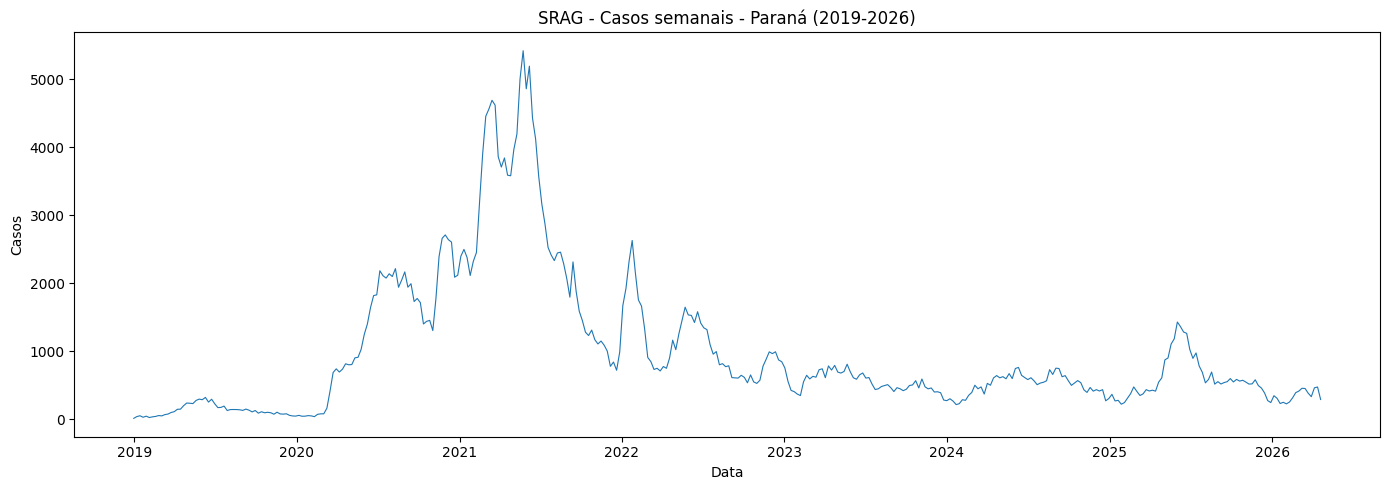

Salvo.


In [49]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_semanal['DT_NOTIFIC'], serie_semanal['casos'], linewidth=0.8)
ax.set_title('SRAG - Casos semanais - Paraná (2019-2026)')
ax.set_xlabel('Data')
ax.set_ylabel('Casos')
plt.tight_layout()
plt.savefig('/home/valentim/divea/outputs/serie_semanal_pr.png', dpi=150)
plt.show()
print("Salvo.")

In [50]:
# Série por vírus
def serie_virus(df, coluna, valor='1', nome=''):
    s = (
        df[df[coluna] == valor]
        .groupby(df['DT_NOTIFIC'].dt.to_period('W'))
        .size()
        .reset_index(name=nome)
    )
    s['DT_NOTIFIC'] = s['DT_NOTIFIC'].dt.to_timestamp()
    return s.set_index('DT_NOTIFIC')

# Influenza
s_flu = serie_virus(df_pr, 'POS_PCRFLU', valor='1', nome='influenza')

# SARS-CoV-2
s_cov = serie_virus(df_pr, 'PCR_SARS2', valor='1', nome='covid')

# VSR
s_vsr = serie_virus(df_pr, 'PCR_VSR', valor='1', nome='vsr')

# Unir com série geral
serie_semanal_idx = serie_semanal.set_index('DT_NOTIFIC')
df_series = serie_semanal_idx.join([s_flu, s_cov, s_vsr]).fillna(0)

print(df_series.shape)
print(df_series.head(10))

(382, 4)
            casos  influenza  covid  vsr
DT_NOTIFIC                              
2018-12-31     13        1.0    0.0  1.0
2019-01-07     39        1.0    0.0  1.0
2019-01-14     51        2.0    0.0  5.0
2019-01-21     29        1.0    0.0  4.0
2019-01-28     45        1.0    0.0  0.0
2019-02-04     25        0.0    0.0  0.0
2019-02-11     35        1.0    0.0  0.0
2019-02-18     41        1.0    0.0  6.0
2019-02-25     54        0.0    0.0  4.0
2019-03-04     49        1.0    0.0  6.0


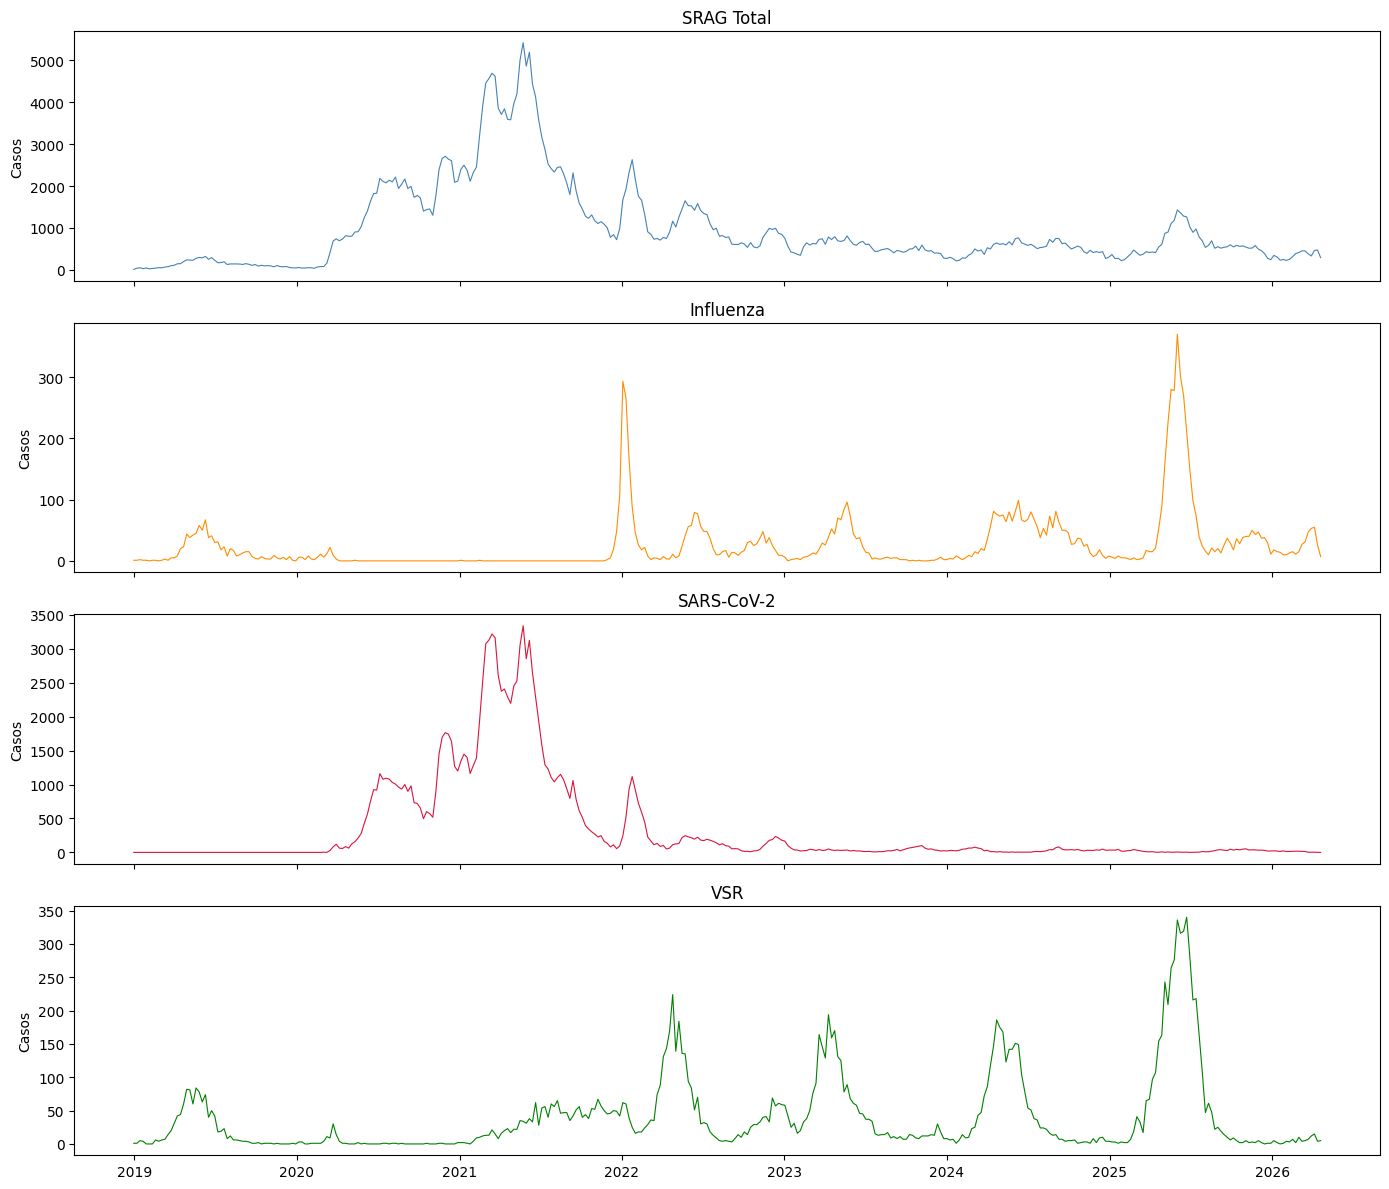

Salvo.


In [51]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

series = ['casos', 'influenza', 'covid', 'vsr']
titulos = ['SRAG Total', 'Influenza', 'SARS-CoV-2', 'VSR']
cores = ['steelblue', 'darkorange', 'crimson', 'green']

for ax, col, titulo, cor in zip(axes, series, titulos, cores):
    ax.plot(df_series.index, df_series[col], color=cor, linewidth=0.8)
    ax.set_title(titulo)
    ax.set_ylabel('Casos')

plt.tight_layout()
plt.savefig('/home/valentim/divea/outputs/series_por_virus.png', dpi=150)
plt.show()
print("Salvo.")

In [52]:
df_series.to_parquet('/home/valentim/divea/data/processed/series_semanais.parquet')
print("Salvo.")

Salvo.


In [53]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Usar série total por enquanto
# Depois replicamos para Influenza, COVID e VSR

serie = df_series['casos'].values.reshape(-1, 1)

# Normalizar entre 0 e 1
scaler = MinMaxScaler()
serie_norm = scaler.fit_transform(serie)

# Criar janelas temporais
# Usa 12 semanas passadas para prever 4 semanas à frente
JANELA = 12
HORIZONTE = 4

X, y = [], []
for i in range(len(serie_norm) - JANELA - HORIZONTE):
    X.append(serie_norm[i:i+JANELA])
    y.append(serie_norm[i+JANELA:i+JANELA+HORIZONTE].flatten())

X = np.array(X)
y = np.array(y)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (366, 12, 1)
y shape: (366, 4)


In [54]:
# 80% treino, 20% teste — mantendo ordem temporal
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 292 amostras
Teste:  74 amostras


In [55]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=4):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# Converter para tensores
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)

model = LSTMModel().to(device)
print(model)

Usando: cuda
LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)


In [56]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 200
losses = []

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_t)
    loss = criterion(output, y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {loss.item():.6f}")

print("\nTreinamento concluído.")

Epoch 20/200 - Loss: 0.038160
Epoch 40/200 - Loss: 0.019132
Epoch 60/200 - Loss: 0.012671
Epoch 80/200 - Loss: 0.010891
Epoch 100/200 - Loss: 0.010427
Epoch 120/200 - Loss: 0.009522
Epoch 140/200 - Loss: 0.009513
Epoch 160/200 - Loss: 0.008701
Epoch 180/200 - Loss: 0.008146
Epoch 200/200 - Loss: 0.008036

Treinamento concluído.


In [57]:
model.eval()
with torch.no_grad():
    pred = model(X_test_t).cpu().numpy()
    real = y_test_t.cpu().numpy()

# Desnormalizar
pred_orig = scaler.inverse_transform(pred)
real_orig = scaler.inverse_transform(real)

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error

for semana in range(4):
    mae = mean_absolute_error(real_orig[:, semana], pred_orig[:, semana])
    rmse = np.sqrt(mean_squared_error(real_orig[:, semana], pred_orig[:, semana]))
    print(f"Semana +{semana+1} — MAE: {mae:.1f} casos | RMSE: {rmse:.1f} casos")

Semana +1 — MAE: 147.9 casos | RMSE: 193.9 casos
Semana +2 — MAE: 181.3 casos | RMSE: 231.8 casos
Semana +3 — MAE: 205.7 casos | RMSE: 263.6 casos
Semana +4 — MAE: 226.9 casos | RMSE: 297.5 casos


In [58]:
# Média e desvio do período de teste
idx_teste = split + JANELA
serie_teste = df_series['casos'].values[idx_teste:]

print(f"Média semanal no período de teste: {serie_teste.mean():.1f}")
print(f"Desvio padrão: {serie_teste.std():.1f}")
print(f"Mínimo: {serie_teste.min()}")
print(f"Máximo: {serie_teste.max()}")

Média semanal no período de teste: 530.1
Desvio padrão: 274.4
Mínimo: 221
Máximo: 1430


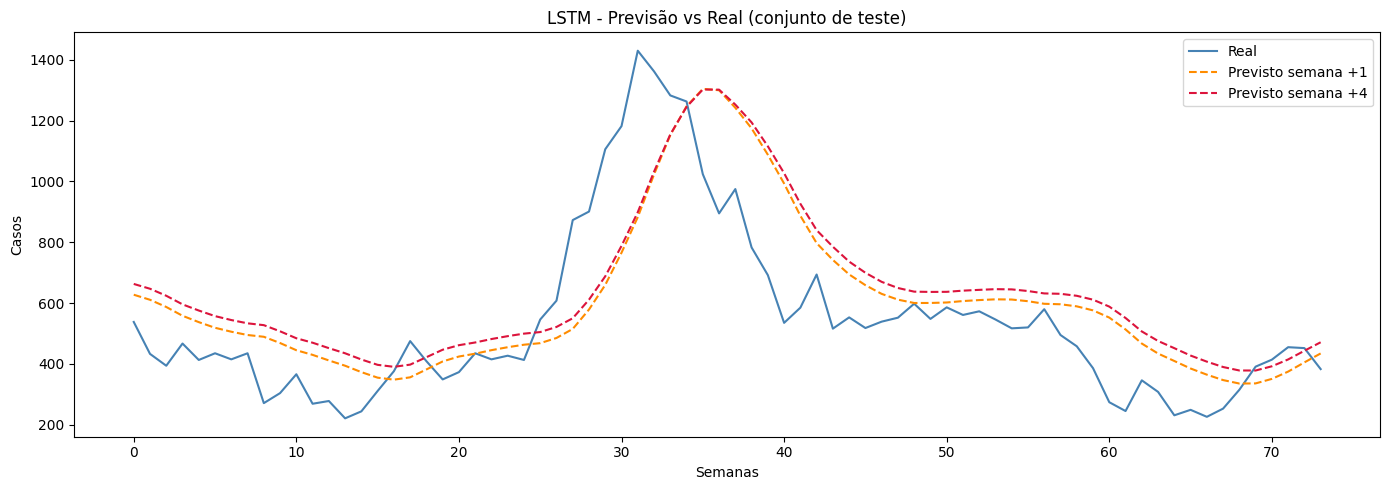

In [59]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(real_orig[:, 0], label='Real', color='steelblue', linewidth=1.5)
ax.plot(pred_orig[:, 0], label='Previsto semana +1', 
        color='darkorange', linewidth=1.5, linestyle='--')
ax.plot(pred_orig[:, 3], label='Previsto semana +4', 
        color='crimson', linewidth=1.5, linestyle='--')

ax.set_title('LSTM - Previsão vs Real (conjunto de teste)')
ax.set_xlabel('Semanas')
ax.set_ylabel('Casos')
ax.legend()
plt.tight_layout()
plt.savefig('/home/valentim/divea/outputs/lstm_predicao.png', dpi=150)
plt.show()

In [60]:
torch.save({
    'model_state': model.state_dict(),
    'scaler': scaler,
    'janela': JANELA,
    'horizonte': HORIZONTE
}, '/home/valentim/divea/models/lstm_srag_total.pt')

print("Modelo salvo.")

Modelo salvo.
